In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
c_const = 3.0e8  
h_const = 6.62607015e-34  
k_const = 1.380649e-23  
T_const = 5000  


In [3]:
data = np.loadtxt('d3.csv', delimiter=',')
wavelengths = data[:, 0]
spectral_radiance = data[:, 1] 

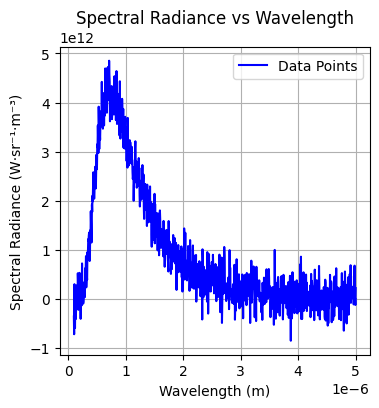

In [4]:
plt.figure(figsize=(4,4))
plt.plot(wavelengths, spectral_radiance, 'b-', label="Data Points")
plt.xlabel('Wavelength (m)')
plt.ylabel('Spectral Radiance (W·sr⁻¹·m⁻³)')
plt.title('Spectral Radiance vs Wavelength')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
def plancks_law(wavelength, T, c, h, k):
    return (2 * h * c**2) / (wavelength**5 * (np.exp((h * c) / (wavelength * k * T)) - 1))

In [6]:
initial_guess = [5000, 3e8, 6.626e-34, 1.38e-23]
params, covariance = curve_fit(plancks_law, wavelengths, spectral_radiance, p0=initial_guess)
T_est, c_est, h_est, k_est = params
print(f"Estimated Parameters:\nT = {T_est}\nc = {c_est}\nh = {h_est}\nk = {k_est}")


Estimated Parameters:
T = 5643.265109212938
c = 203908212.97721803
h = 1.3592714461479177e-33
k = 1.3801282927296255e-23


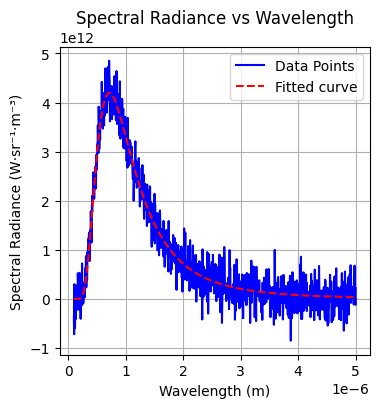

In [7]:
plt.figure(figsize=(4,4))
plt.plot(wavelengths, spectral_radiance, 'b-', label="Data Points")
plt.plot(wavelengths, plancks_law(wavelengths, *params), 'r--', label="Fitted curve")
plt.xlabel('Wavelength (m)')
plt.ylabel('Spectral Radiance (W·sr⁻¹·m⁻³)')
plt.title('Spectral Radiance vs Wavelength')
plt.legend()
plt.grid(True)
plt.show()

When fitting all four parameters (T, c, h, k) simultaneously, the problem becomes highly non-linear and complex.The values for the constants h, c, k are far from the actual values.
The optimization algorithm may struggle to find the global minimum, leading to poor estimates.
This is likely due to the strong interdependencies between the parameters, making it difficult to 
accurately estimate each of them without prior information or constraints.

To address this, we perform partial application by fixing some parameters to their known values 
and estimating the remaining ones. This reduces the complexity of the fitting process and often yields 
more accurate results.

Partial application of each unknown

Fitted T = 4.00e+03
Fitted c = 4.32e+08
Fitted h = 8.75e-34
Fitted k = 1.11e-23


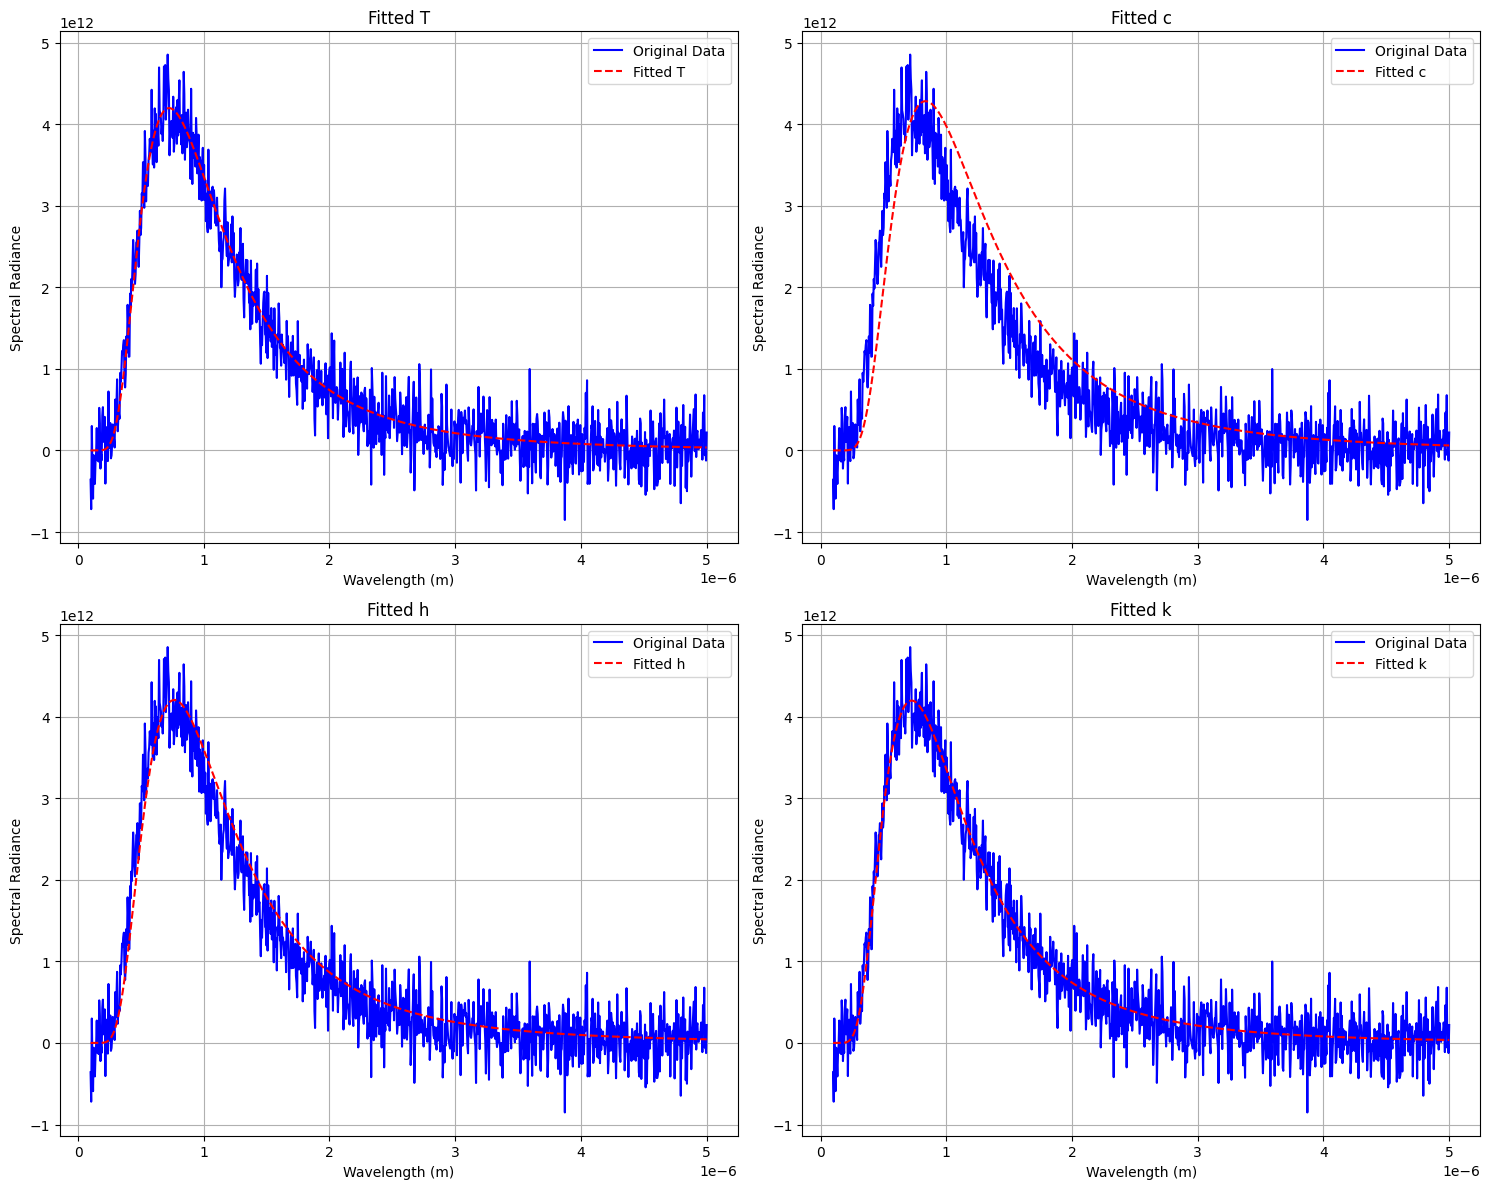

In [8]:
def planck_T(wavelength, T):
    return (2 * h_const * c_const**2) / (wavelength**5 * (np.exp((h_const * c_const) / (wavelength * k_const * T)) - 1))

def planck_c(wavelength, c):
    return (2 * h_const * c**2) / (wavelength**5 * (np.exp((h_const * c) / (wavelength * k_const * T_const)) - 1))

def planck_h(wavelength, h):
    return (2 * h * c_const**2) / (wavelength**5 * (np.exp((h * c_const) / (wavelength * k_const * T_const)) - 1))

def planck_k(wavelength, k):
    return (2 * h_const * c_const**2) / (wavelength**5 * (np.exp((h_const * c_const) / (wavelength * k * T_const)) - 1))

def fit_planck_model(planck_func, p0, label, wavelengths, spectral_radiance):
    param, _ = curve_fit(planck_func, wavelengths, spectral_radiance, p0=p0)
    return param[0], f"Fitted {label} = {param[0]:.2e}"

initial_guesses = {
    'T': [T_const],
    'c': [c_const],
    'h': [h_const],
    'k': [k_const]
}

planck_models = {
    'T': (planck_T, initial_guesses['T']),
    'c': (planck_c, initial_guesses['c']),
    'h': (planck_h, initial_guesses['h']),
    'k': (planck_k, initial_guesses['k'])
}

results = {}
for label, (func, guess) in planck_models.items():
    param, message = fit_planck_model(func, guess, label, wavelengths, spectral_radiance)
    results[label] = (param, message)
    
for label, (_, message) in results.items():
    print(message)

def plot_fit(ax, wavelength, radiance, model_func, param, label):
    ax.plot(wavelength, radiance, 'b-', label='Original Data')
    ax.plot(wavelength, model_func(wavelength, param), 'r--', label=f'Fitted {label}')
    ax.set_xlabel('Wavelength (m)')
    ax.set_ylabel('Spectral Radiance')
    ax.set_title(f'Fitted {label}')
    ax.legend()
    ax.grid(True)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plot_fit(axes[0, 0], wavelengths, spectral_radiance, planck_T, results['T'][0], 'T')
plot_fit(axes[0, 1], wavelengths, spectral_radiance, planck_c, results['c'][0], 'c')
plot_fit(axes[1, 0], wavelengths, spectral_radiance, planck_h, results['h'][0], 'h')
plot_fit(axes[1, 1], wavelengths, spectral_radiance, planck_k, results['k'][0], 'k')

plt.tight_layout()
plt.show()


Fitting one parameter at a time with partial application allows us to isolate the effect of that parameter on the curve.
This simplifies the optimization problem and makes it more likely to find an accurate estimate for the chosen parameter.
By fixing other parameters to their known values, we reduce the interdependencies and focus on the influence of the target parameter.


Partial application of pair of unknowns

Estimated parameters for T_c:
  3.94e+03, 2.92e+08
Estimated parameters for T_h:
  3.83e+03, 6.28e-34
Estimated parameters for T_k:
  6.18e+03, 8.94e-24
Estimated parameters for c_h:
  2.30e+08, 1.07e-33
Estimated parameters for c_k:
  2.92e+08, 1.09e-23
Estimated parameters for h_k:
  6.28e-34, 1.06e-23


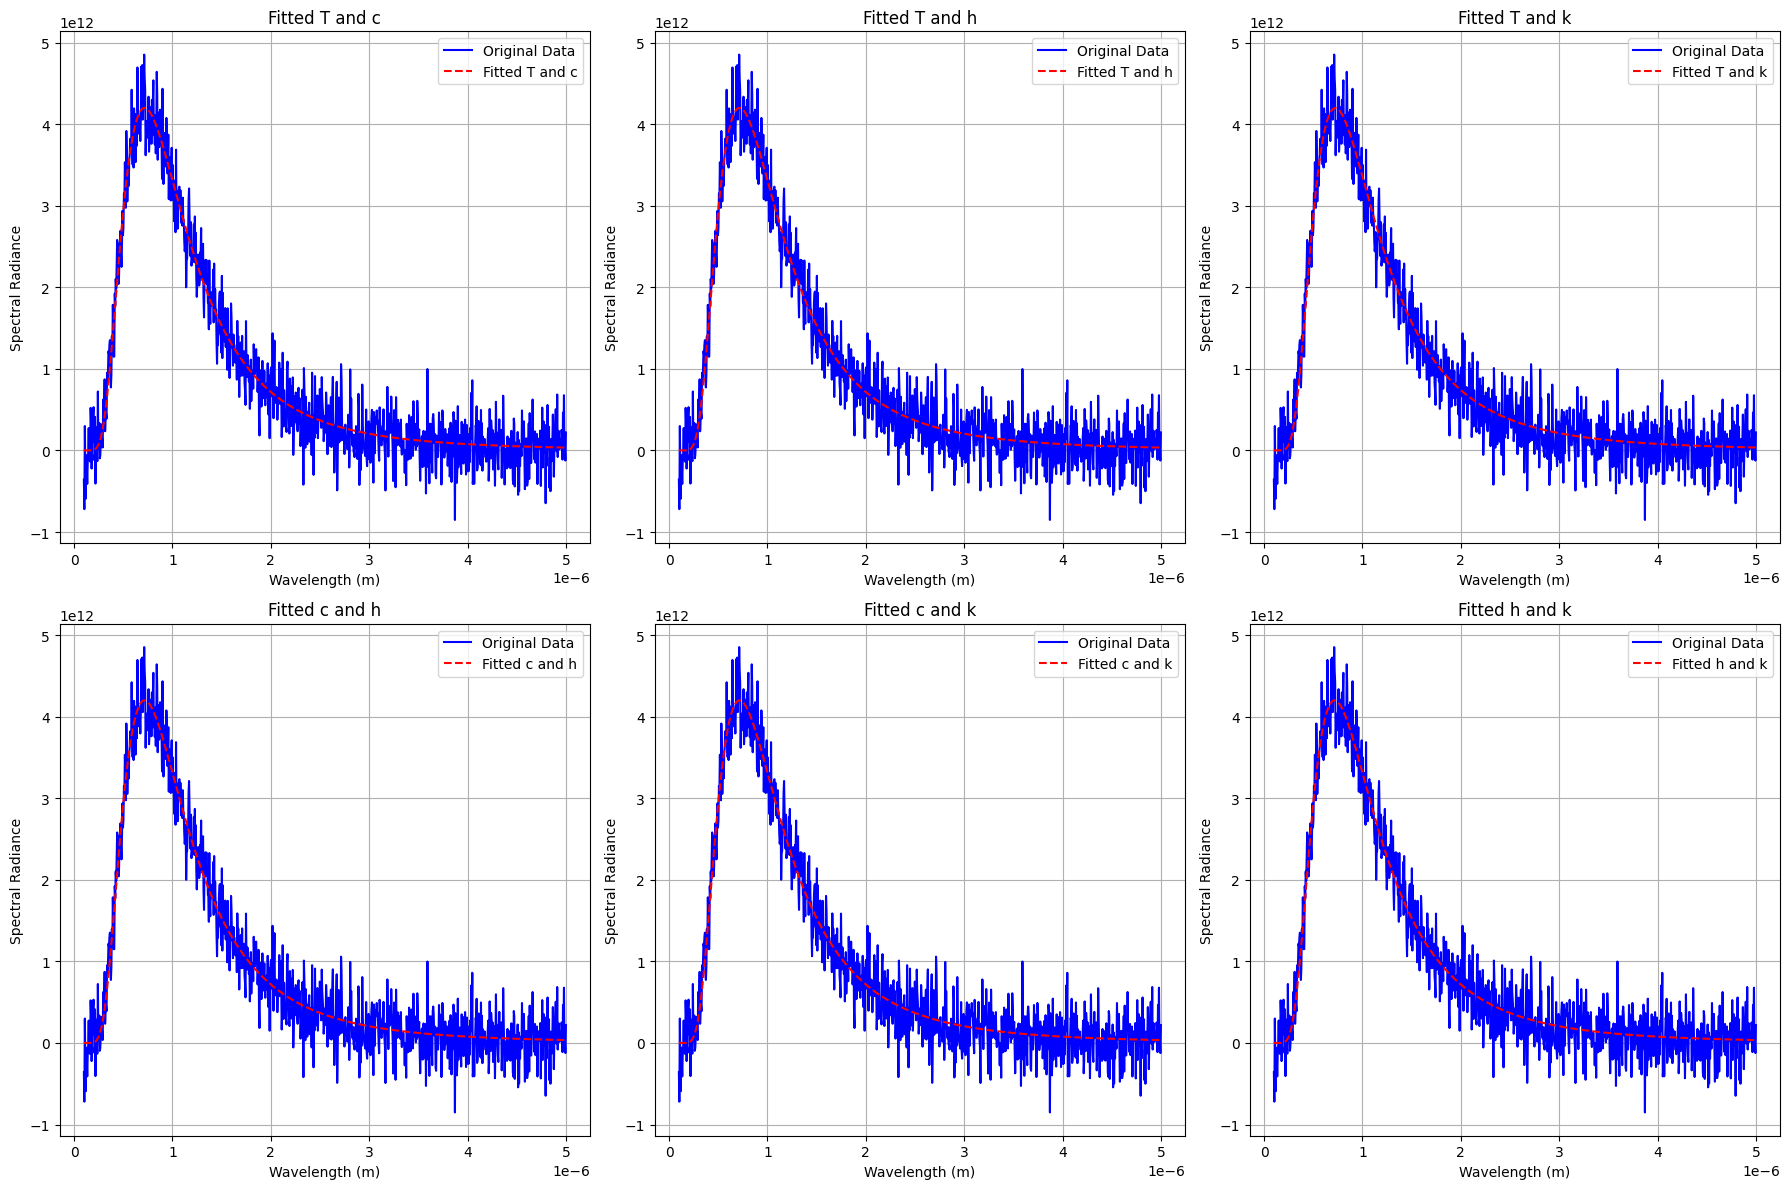

In [9]:
def planck_T_c(wavelength, T, c):
    return (2 * h_const * c**2) / (wavelength**5 * (np.exp((h_const * c) / (wavelength * k_const * T)) - 1))

def planck_T_h(wavelength, T, h):
    return (2 * h * c_const**2) / (wavelength**5 * (np.exp((h * c_const) / (wavelength * k_const * T)) - 1))

def planck_T_k(wavelength, T, k):
    return (2 * h_const * c_const**2) / (wavelength**5 * (np.exp((h_const * c_const) / (wavelength * k * T)) - 1))

def planck_c_h(wavelength, c, h):
    return (2 * h * c**2) / (wavelength**5 * (np.exp((h * c) / (wavelength * k_const * T_const)) - 1))

def planck_c_k(wavelength, c, k):
    return (2 * h_const * c**2) / (wavelength**5 * (np.exp((h_const * c) / (wavelength * k * T_const)) - 1))

def planck_h_k(wavelength, h, k):
    return (2 * h * c_const**2) / (wavelength**5 * (np.exp((h * c_const) / (wavelength * k * T_const)) - 1))

models = {
    'T_c': (planck_T_c, [T_const, c_const]),
    'T_h': (planck_T_h, [T_const, h_const]),
    'T_k': (planck_T_k, [T_const, k_const]),
    'c_h': (planck_c_h, [c_const, h_const]),
    'c_k': (planck_c_k, [c_const, k_const]),
    'h_k': (planck_h_k, [h_const, k_const])
}
results = {label: curve_fit(func, wavelengths, spectral_radiance, p0=p0) for label, (func, p0) in models.items()}
params = {label: result[0] for label, result in results.items()}

for label, param_values in params.items():
    print(f"Estimated parameters for {label}:")
    print(f"  {', '.join(f'{val:.2e}' for val in param_values)}")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

def plot_results(ax, model_func, params, label):
    ax.plot(wavelengths, spectral_radiance, 'b-', label='Original Data')
    ax.plot(wavelengths, model_func(wavelengths, *params), 'r--', label=f'Fitted {label}')
    ax.set_xlabel('Wavelength (m)')
    ax.set_ylabel('Spectral Radiance')
    ax.set_title(f'Fitted {label}')
    ax.legend()
    ax.grid(True)

plot_results(axes[0, 0], planck_T_c, params['T_c'], 'T and c')
plot_results(axes[0, 1], planck_T_h, params['T_h'], 'T and h')
plot_results(axes[0, 2], planck_T_k, params['T_k'], 'T and k')
plot_results(axes[1, 0], planck_c_h, params['c_h'], 'c and h')
plot_results(axes[1, 1], planck_c_k, params['c_k'], 'c and k')
plot_results(axes[1, 2], planck_h_k, params['h_k'], 'h and k')

plt.tight_layout()
plt.show()


Estimating two parameters at a time is a compromise between the complexity of full parameter estimation
and the simplicity of single parameter estimation. By pairing parameters, we can capture some of their
interdependencies without overcomplicating the fitting process. This approach can improve the accuracy of
estimation for both parameters while still reducing the risk of convergence to local minima.

However, pairing parameters introduces more complexity compared to single parameter estimation and can
still lead to suboptimal results if the initial guesses are not close to the true values. Thus, 
careful selection of pairs and initial conditions is crucial.